# Xi Line Chart

Plot `xi`, `xi_dir`, or `xi_amp` for all countries as thin transparent gray lines, with optional highlighted countries in thicker color.

In [40]:
from pathlib import Path
import os
import sys
import importlib

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from io_networks.config import load_config
import io_networks.viz_xi as viz_xi
importlib.reload(viz_xi)

load_xi_data = viz_xi.load_xi_data
plot_xi_country_lines = viz_xi.plot_xi_country_lines
select_phase_map_countries = viz_xi.select_phase_map_countries
plot_xi_phase_map = viz_xi.plot_xi_phase_map

import matplotlib.pyplot as plt

In [41]:
cfg = load_config('config/default.yaml')
variant = None  # None -> inferred from config (regular/extended)
metric = 'xi'  # 'xi', 'xi_dir', 'xi_amp_1', 'xi_amp_2', 'xi_amp', 'share', 'share_amp_1', or 'share_amp_2'
yscale = 'linear'  # linear, log, or symlog
highlight_countries = ['USA', 'GBR', 'DEU', 'CHN', 'PER']  # optional: highlight specific countries
#['UKR', 'CHN', 'IND', 'BRA', 'MEX'] selection of developing countries with large populations and/or land area, and significant global influence
#['GBR', 'JPN', 'DEU', 'USA', 'AUS'] selection of developed countries with large economies and/or land area, and significant global influence
exclude_countries = []  # optional: hide outliers from main panel
show_background = False  # toggle gray background lines for non-highlighted countries
label_pad_years = 1.5  # reserve right-side space for direct end labels
end_label_fontsize = 11  # font size for right-side end labels
reference_year_labels = {2008.0: 'Great Financial Crisis', 2020.0: 'COVID'}
reference_label_y = 0.98  # vertical position in axes coordinates (0=bottom, 1=top)
reference_label_x_offset = -0.12  # horizontal offset in year units from the dotted line
reference_label_rotation = 0
reference_label_fontsize = 15
reference_label_color = 'black'
reference_label_ha = 'right'

In [42]:
df = load_xi_data(cfg=cfg, variant=variant)
print('rows:', len(df))
print('years:', int(df['year'].min()), 'to', int(df['year'].max()))
if 'status' in df.columns:
    print('status counts:', df['status'].value_counts(dropna=False).to_dict())
df_preview = df.copy()
denom = df_preview['xi'].replace(0.0, float('nan'))
if metric == 'share':
    df_preview['share'] = df_preview['xi_amp'] / denom
elif metric == 'share_amp_1':
    df_preview['share_amp_1'] = df_preview['xi_amp_1'] / denom
elif metric == 'share_amp_2':
    df_preview['share_amp_2'] = df_preview['xi_amp_2'] / denom
print(df_preview[['year', 'country', metric, 'status']].head(10).to_string(index=False))

rows: 2268
years: 1995 to 2022
status counts: {'ok': 2268}
 year country       xi status
 1995     AGO 0.083686     ok
 1995     ARE 0.105012     ok
 1995     ARG 0.064123     ok
 1995     AUS 0.021698     ok
 1995     AUT 0.020677     ok
 1995     BEL 0.036440     ok
 1995     BGD 0.019021     ok
 1995     BGR 0.038781     ok
 1995     BLR 0.103507     ok
 1995     BRA 0.105458     ok


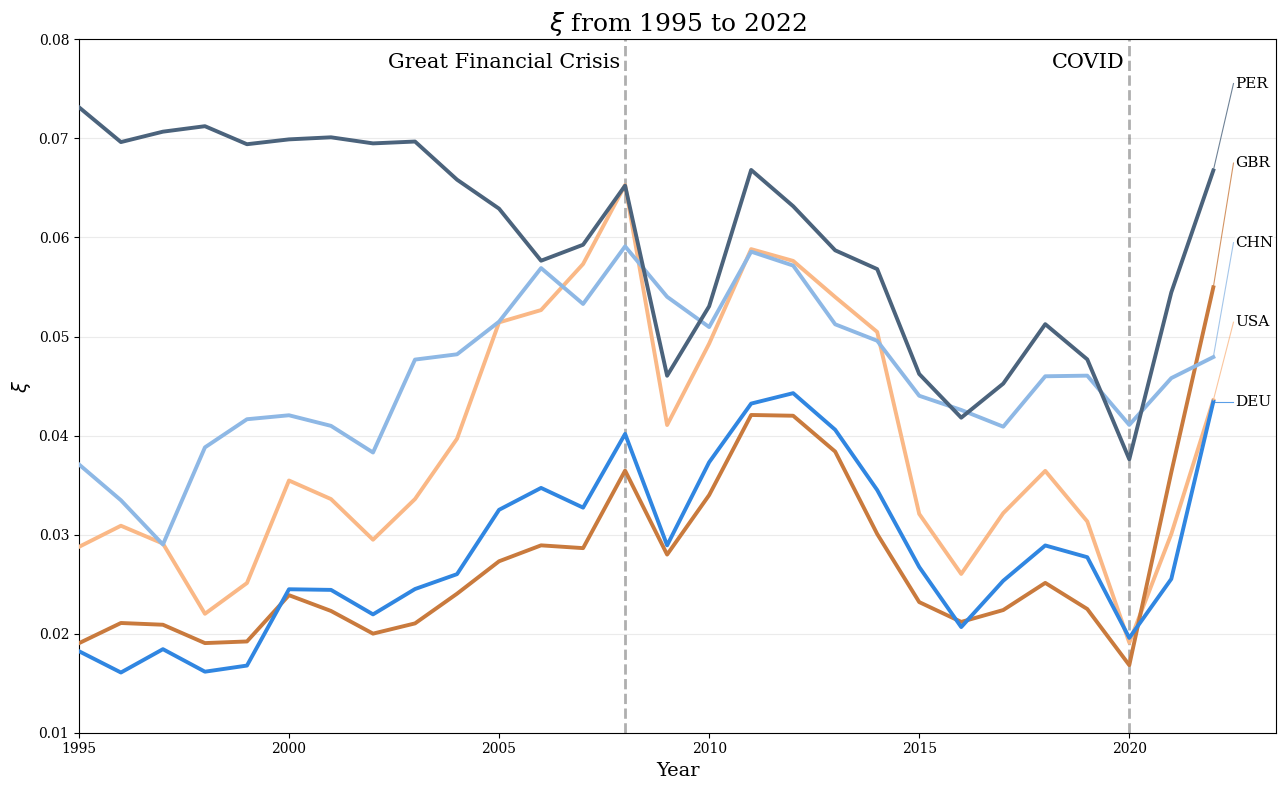

In [45]:
from cycler import cycler

# Set the color cycle for the plot
plt.rc('axes', prop_cycle=cycler('color', ["#fab886", '#c97a3d', "#3086e1", '#8eb8e5', "#4b637c"]))


fig, ax = plt.subplots(figsize=(13, 8))
metric_labels = {
    'xi': r'$\xi$',
    'xi_dir': r'$\xi_{dir}$',
    'xi_amp_1': r'$\xi_{near}$',
    'xi_amp_2': r'$\xi_{deep}$',
    'xi_amp': r'$\xi_{amp}$',
    'share': r'$\xi_{amp} / \xi$',
    'share_amp_1': r'$\xi_{amp,1} / \xi$',
    'share_amp_2': r'$\xi_{amp,2} / \xi$',
}
metric_label = metric_labels.get(metric, metric)
plot_xi_country_lines(
    df,
    metric=metric,
    highlight_countries=highlight_countries,
    exclude_countries=exclude_countries,
    only_ok=True,
    yscale=yscale,
    title=rf'{metric_label} over time',
    show_background=show_background,
    alpha_bg=0.15,
    lw_bg=0.8,
    lw_hi=2.8,
    use_end_labels=True,
    show_legend=False,
    end_label_fontsize=end_label_fontsize,
    label_pad_years=label_pad_years,
    reference_year_labels=reference_year_labels,
    reference_label_y=reference_label_y,
    reference_label_x_offset=reference_label_x_offset,
    reference_label_rotation=reference_label_rotation,
    reference_label_fontsize=reference_label_fontsize,
    reference_label_color=reference_label_color,
    reference_label_ha=reference_label_ha,
    ax=ax,
)

'''
ymin = 0.003
ymax = 0.10
ax.set_ylim(ymin, ymax)   # lower, upper
'''

ymin = 0.01
ymax = 0.08
ax.set_ylim(ymin, ymax)   # lower, upper
ax.set_title(rf"{metric_label} from 1995 to 2022", fontfamily="serif", fontsize=18)
ax.set_ylabel(rf"{metric_label}", fontfamily='serif', fontsize=14)
ax.set_xlabel(rf"Year", fontfamily='serif', fontsize=14)

plt.tight_layout()
plt.show()